In [11]:
import pandas as pd

df = pd.read_csv("weather_dataset_2025.csv")

df.head()


,Date,City,Temperature_C,Humidity_%,Wind_Speed_km_h,Precipitation_mm,Condition
0,2025-01-01,Riyadh,15.8,94,21.0,0.00,Cloudy
1,2025-01-01,Jeddah,31.5,54,25.3,3.71,Windy
2,2025-01-01,Dammam,30.4,33,8.6,3.14,Partly Cloudy
3,2025-01-01,Dubai,34.0,37,18.7,0.00,Foggy
4,2025-01-01,Doha,28.3,32,6.8,0.00,Rainy


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5475 entries, 0 to 5474
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              5475 non-null   object 
 1   City              5475 non-null   object 
 2   Temperature_C     5475 non-null   float64
 3   Humidity_%        5475 non-null   int64  
 4   Wind_Speed_km_h   5475 non-null   float64
 5   Precipitation_mm  5475 non-null   float64
 6   Condition         5475 non-null   object 
dtypes: float64(3), int64(1), object(3)
memory usage: 299.5+ KB


2. Data Cleaning


In [10]:
df['Date'] = pd.to_datetime(df['Date'])

In [13]:
# Check missing values
print(df.isnull().sum())

Date                0
City                0
Temperature_C       0
Humidity_%          0
Wind_Speed_km_h     0
Precipitation_mm    0
Condition           0
dtype: int64


In [14]:
#Remove duplicates
df.drop_duplicates(inplace=True)

3. Feature Engineering

In [18]:
df['Date'] = pd.to_datetime(df['Date'])
df.dtypes

Date                datetime64[ns]
City                        object
Temperature_C              float64
Humidity_%                   int64
Wind_Speed_km_h            float64
Precipitation_mm           float64
Condition                   object
day                          int32
month                        int32
dayofweek                    int32
dtype: object

In [17]:
df['day'] = df['Date'].dt.day
df['month'] = df['Date'].dt.month
df['dayofweek'] = df['Date'].dt.dayofweek

4. EDA (this is where marks come ✅)

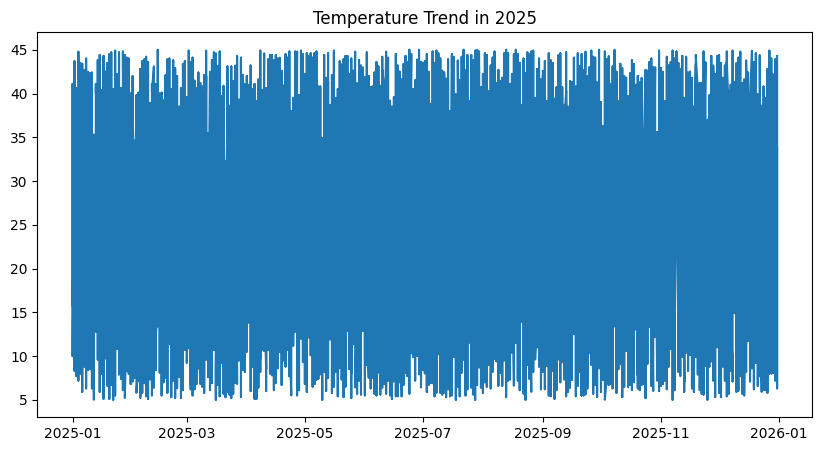

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Temperature_C'])
plt.title("Temperature Trend in 2025")
plt.show()

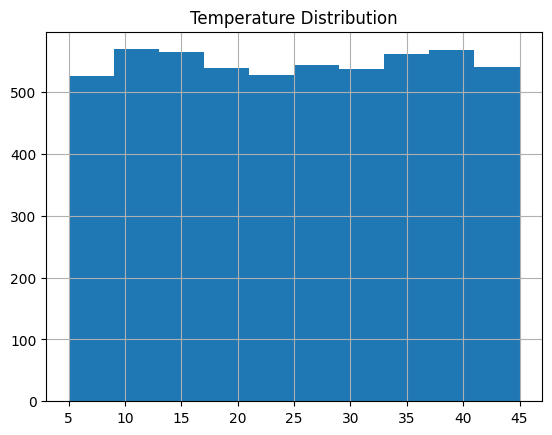

In [20]:
#Distribution
df['Temperature_C'].hist()
plt.title("Temperature Distribution")
plt.show()

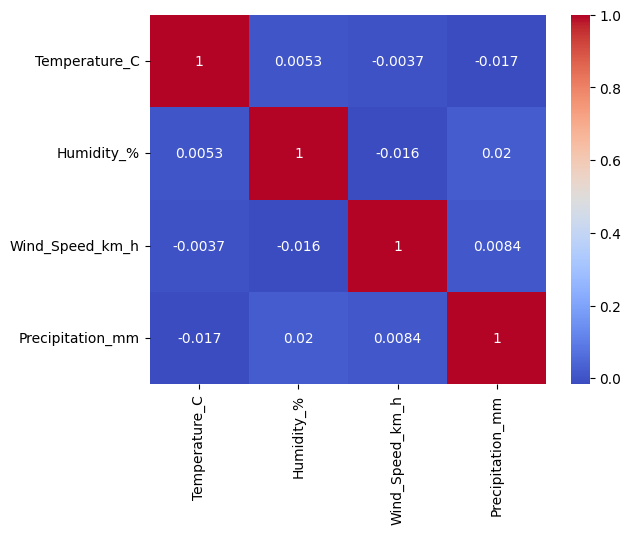

In [26]:
# Correlation
import seaborn as sns

sns.heatmap(df[['Temperature_C','Humidity_%','Wind_Speed_km_h','Precipitation_mm']].corr(), annot=True,cmap='coolwarm')
plt.show()

Weather condition analysis

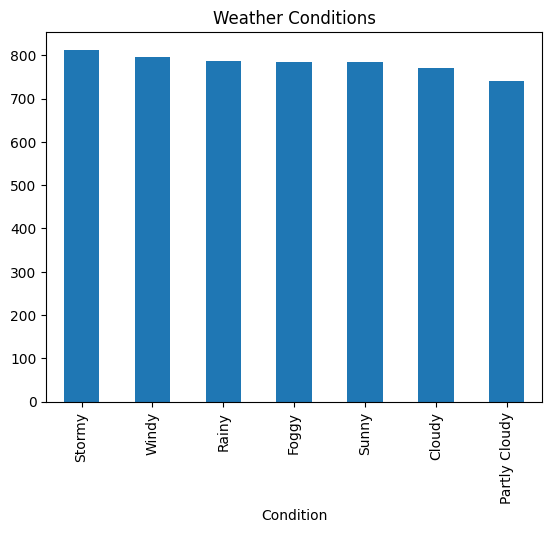

In [27]:
df['Condition'].value_counts().plot(kind='bar')
plt.title("Weather Conditions")
plt.show()

In [28]:
#5. Handle Outliers (important)
import numpy as np

df['Temperature_C'] = np.clip(df['Temperature_C'], -10, 50)

In [29]:
#6. Normalization
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[['Temperature_C','Humidity_%','Wind_Speed_km_h','Precipitation_mm']] = scaler.fit_transform(
    df[['Temperature_C','Humidity_%','Wind_Speed_km_h','Precipitation_mm']]
)

In [30]:
#7. Prepare Time Series
city_df = df[df['City'] == "Riyadh"]

city_df = city_df.sort_values('Date')

city_df.set_index('Date', inplace=True)

In [ ]:
!pip install prophet

C:\Users\SH173SF\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
18:46:59 - cmdstanpy - INFO - Chain [1] start processing
18:47:02 - cmdstanpy - INFO - Chain [1] done processing


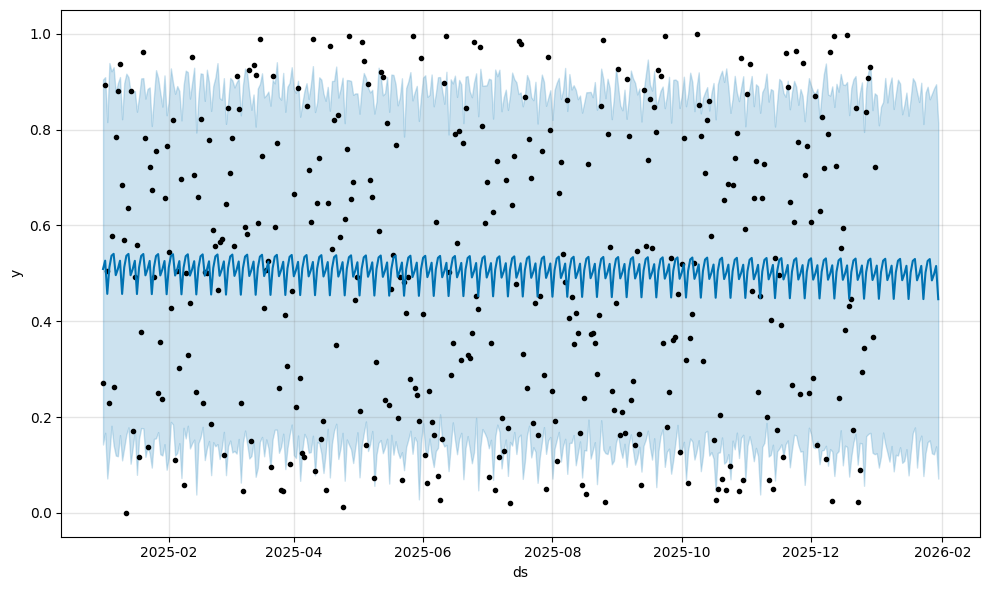

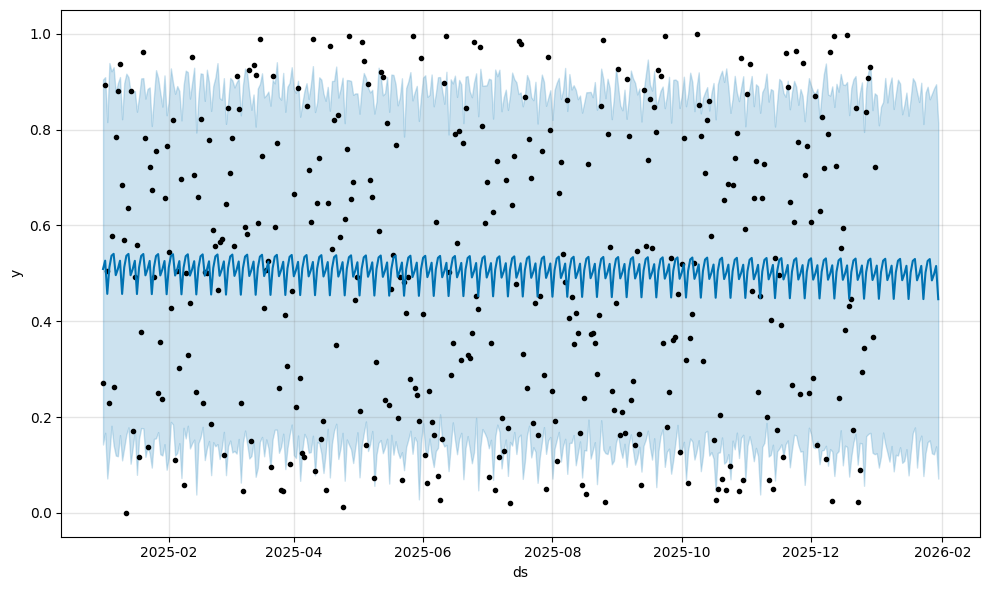

In [32]:
# 8. Model Selection
from prophet import Prophet

ts = city_df.reset_index()[['Date','Temperature_C']]
ts.columns = ['ds','y']

model = Prophet()
model.fit(ts)

future = model.make_future_dataframe(periods=30)  # forecast 30 days

forecast = model.predict(future)

model.plot(forecast)